In [950]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [951]:
def f(x):
    return 3*(x**2) -4*x + 5

In [952]:
f(3.0)

20.0

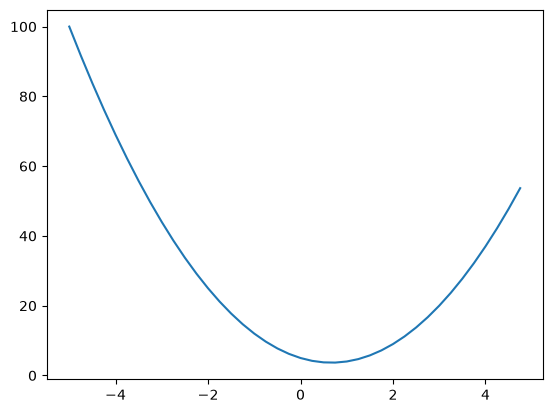

In [953]:
xs = np.arange(-5,5,0.25)
plt.plot(xs,f(xs))

In [954]:
#implementing derivation numerically (lim h->0 (f(x+h)-f(x)/h)

h=0.0000000001 #maxed out float  representation
x=1/2
(f(x+h)-f(x))/h

-1.000000082740371

In [955]:
#more complex case
a=2.0
b=-3.0
c=10.0
d=a*b+c #d is a func of a,b and c 
print(d) 

4.0


In [956]:
h=00000.1
#inputs
a=2.0
b=-3.0
c=10.0
  
d1=a*b+c
c+=h
d2 = a*b+c

print('d1',d1)
print('d2',d2)
print('slope',(d2-d1)/h) 


d1 4.0
d2 4.1
slope 0.9999999999999964


In [957]:
class Value:
    def __init__(self,data,_children=(), _op='', label=''): #default empty tuple for children, empty string for op
        self.data=data
        self._prev = set(_children)
        self._op=_op
        self._backward = lambda: None
        self.label=label
        self.grad = 0.0 
    def __repr__(self):
        return f"Value(data={self.data})"
    #for all gradient calculations, we have to use +='s in the scenario where a value gets passed over twice
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # to allow expressions of the kind a+8
        out = Value(self.data+other.data, (self,other), _op='+')
        def _backward(): 
            self.grad +=1.0 * out.grad
            other.grad +=1.0 * out.grad
        out._backward  = _backward
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # to allow expressions of the kind a*8
        out = Value(self.data*other.data, (self,other), _op='*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward=_backward
        return out
    def tanh(self):
        out = Value((math.exp(2*self.data)-1)/(math.exp(2*self.data)+1), (self,), _op='tanh')
        def _backward():
            self.grad += (1-(out.data**2)) * out.grad
        out._backward=_backward
        return out

    def __pow__(self, pow): #value**k
        assert isinstance(pow, (int,float)), "only supporting int and float powers"
        out = Value(self.data**pow, (self, ), _op=f"**{pow}")
        def _backward():  
                self.grad += pow*(self.data**(pow-1)) * out.grad
        out._backward=_backward
        return out   

    def __neg__(self): #-self
        return self * -1
    
    def __sub__(self,other):#self - other  
        other = other if isinstance(other,Value) else Value(other) 
        return self + (-other)

    
 
    def __rmul__(self,other): #other*self
        return self*other #to allow 2 * a kind of operations. 
    
    __radd__ = __add__

    def exp(self):
        out = Value(math.exp(self.data), (self,),_op='exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward=_backward
        return out

    def __truediv__(self, other): #self/other
        return self*(other**-1)

    def backward(self): # only on DAGs
        topo = []
        visited = set()
        def _build_topo(value):
            if value not in visited:
                visited.add(value)
                for child in value._prev:
                    _build_topo(child)
                topo.append(value)
        _build_topo(self)
        self.grad=1.0; #assuming autograd is called on the output node
        topo.reverse() # Post-fix DFS -> Topological Search
        for value in topo:
            value._backward() #.  iterative autograd
    
    
        
 
x=Value(6.7, label='x')
y=Value(2.3, label='y')
z=Value(7.1, label='z') 
w=x*y;w.label='w' 
k=w+z;k.label='k'
t = Value(-2.0, label='t')
P = k*t;P.label='P' 

In [958]:
k._prev

{Value(data=15.409999999999998), Value(data=7.1)}

In [959]:
k._op

'+'

In [960]:
from graphviz import Digraph

def trace(root):
    #builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child) 
    build(root)
    return nodes, edges
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right 

    nodes, edges = trace(root)
    for n in nodes:
        uid=str(id(n))
        #for any value in the graph, create a rectangular table-like ('record') node for it
        dot.node(name=uid, label = " { %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:  
            #if this value is the result of some operations create an op node for it
            dot.node(name=uid + n._op, label = n._op) 
            #and connect this node to it
            dot.edge(uid+n._op,uid)
    for n1,n2 in edges:
        #connect n1 to the op node of n2
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    return dot

In [961]:
P.grad=1.0
k.grad=t.data
t.grad=k.data
z.grad=t.data
w.grad=t.data
y.grad=x.data*t.data
x.grad=y.data*t.data
#manual gradient calculus

#let's now tweak the wrights to grow P according to the gradients
t.data+=1.  


#re-assembling here to account for weight tweaks
w=x*y;w.label='w'
k=w+z;k.label='k'
P = k*t;P.label='P' 

#re-doing the grad computations
P.grad=1.0
k.grad=t.data
t.grad=k.data
z.grad=t.data
w.grad=t.data
y.grad=x.data*t.data
x.grad=y.data*t.data


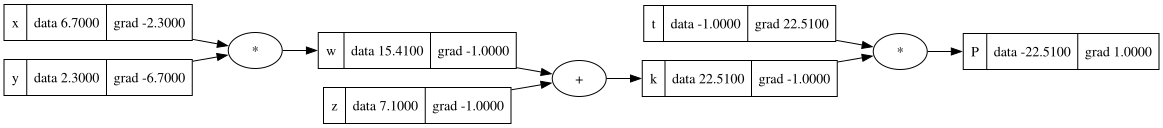

In [962]:
draw_dot(P)

In [963]:
def lol():
    h=0.0001

    x=Value(6.7, label='x')
    y=Value(2.3, label='y')
    z=Value(7.1, label='z')
    w=x*y;w.label='w'   
    k=w+z;k.label='k'
    t = Value(-2.0, label='f')
    P = k*t;P.label='P' 

    P1 = P.data

    x=Value(6.7, label='x')
    y=Value(2.3, label='y')
    z=Value(7.1, label='z')
    w=x*y;w.label='w' 
    k=w+z;k.label='k'
    t = Value(-2.0, label='f')
    P = k*t;P.label='P' 

    P2=P.data + h
    print((P2-P1)/h) 

lol() 
   

1.0000000000331966


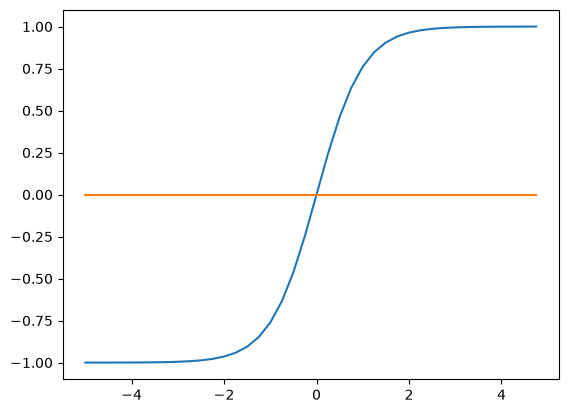

In [964]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

plt.plot(xs,np.tanh(xs))
plt.plot(xs,np.zeros_like(xs)) 

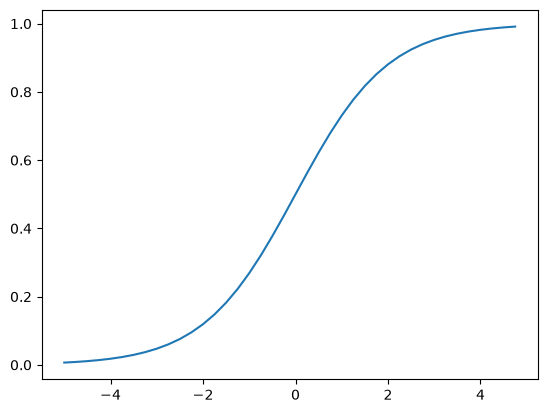

In [965]:
plt.plot(xs,sigmoid(xs))

In [966]:
#input x1,x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0, label='x2')
#weights w1,w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0, label='w2')
#bias of the neuron
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1;x1w1.label='x1w1'
x2w2= x2*w2;x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2;x1w1x2w2.label='x1w1+x2w2'
n = x1w1x2w2 + b; n.label='n' 

o=n.tanh();o.label='o'

##grad
#o.grad=1.0
#manually
# o = tanh(n) do/dn = 1-tanh(n)^2 = 1-o^2
#n.grad = 1-o.data**2 
#do/db = do/dn * dn/db
#dn/db = b+x1w1x2w2/db = 1
#b.grad=n.grad
#symetrically :
#x1w1x2w2.grad=n.grad
#similarly than above
#x2w2.grad=x1w1x2w2.grad
#x1w1.grad=x1w1x2w2.grad
#now using a times node 
#x1.grad=x1w1.grad*w1.data
##w1.grad=x1w1.grad*x1.data
#x2.grad=x2w2.grad*w2.data
#w2.grad=x2w2.grad*x2.data
#using backward calling
#o._backward()
#n._backward()
#x1w1x2w2._backward()
#x2w2._backward()
#x1w1._backward()

# To now implement autograd on a DAG, we need to use topological sort (implemented in the Value class) 

o.backward()      


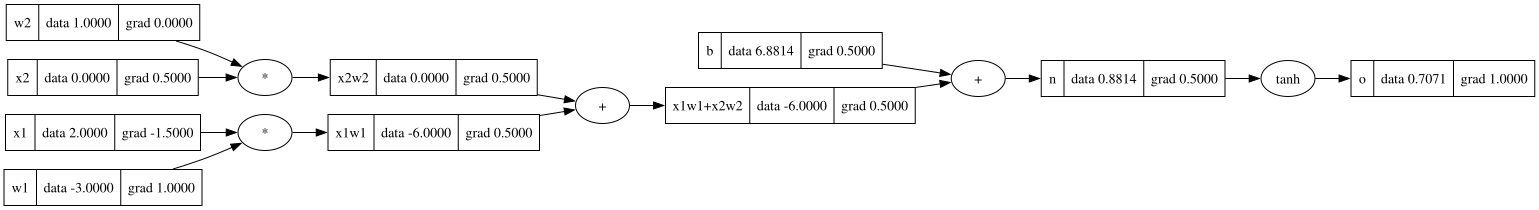

In [967]:

draw_dot(o)

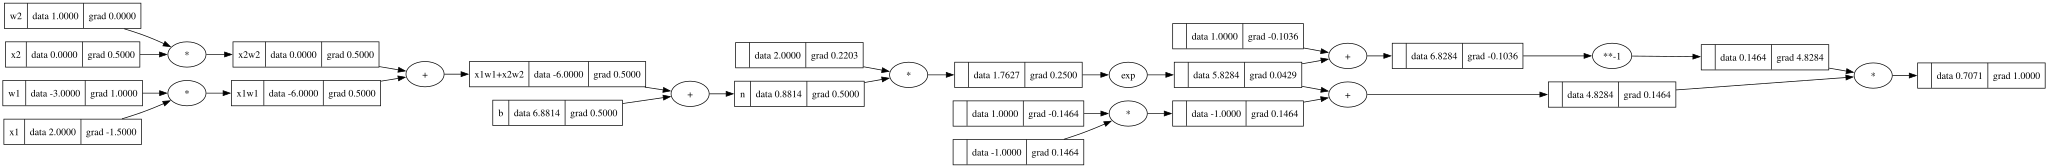

In [968]:
#building tanh() atomically rather than using func
x1 = Value(2.0,label='x1')
x2 = Value(0.0, label='x2')
#weights w1,w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0, label='w2')
#bias of the neuron
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1;x1w1.label='x1w1'
x2w2= x2*w2;x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2;x1w1x2w2.label='x1w1+x2w2'
n = x1w1x2w2 + b; n.label='n' 

e=(2*n).exp()
o=(e-1)/(e+1)
o.backward()
draw_dot(o)

In [969]:
#reproducing backprop using pytorch this time
import torch

#input
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
#weights
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True 
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True 
#bias
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
#since all the tensors are leaf nodes for now, we need to explicitly require gradient
n = w1*x1 + w2*x2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()
print('x2', x2.grad.item())
print('x1', x1.grad.item())
print('w2', w2.grad.item())
print('w1', w1.grad.item())

#when ran, they output the same correct values we got from micrograd earlier.  



0.7071066904050358
x2 0.5000001283844369
x1 -1.5000003851533106
w2 0.0
w1 1.0000002567688737


In [ ]:
import random 

#let's match the PyTorch's API on the Neural network module now

#Neuron
class Neuron:
    def __init__(self, nin):
        self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b=Value(random.uniform(-1,1))
    def __call__(self,x):
        #w*x+b, dot product of w and x vectors, which is then reduced and added the bias
        #x needs to be a vector of the same dimension as self.w obviously
        acc = sum((wi*xi for wi,xi in zip(self.w,x)), self.b) ##reducing as we compute the dot product
        return acc.tanh()
    def parameters(self):
        return self.w + [self.b] #concat list of weights and biases
#Layer
class Layer:
    def __init__(self, ndim, nnum):
        self.neurons = [Neuron(ndim) for _ in range(nnum)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]


#Multi layer perceptron (MLP)
class MLP():
    def __init__(self, nin, nout):#nout is a list, it represent the number of neurons at layer index i
        sz = [nin] + nout
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nout))] #array of layers, each of size nout[i] and of dim   

    def __call__(self, x):
        for layer in self.layers:
            x=layer(x)
        return x #i.e recursively, we have base input x, which gets transformed by layer 0, and the output o that transfo feeds layer 1 all the way till layer nout.len which is the output 
    def parameters(self):
        return [p for l in self.layers for p in l.parameters()]
    def train(self, iter, step, data, expec):
        for k in range(iter):
            #first we do a forward pass
            ypred=[self(x) for x in data]

            #then we evaluate the loss on that forward pass
            loss = sum([(yout-ygt)**2 for ygt, yout in zip(expec,ypred)]) #    Σ(predicted-expected)^2

            #then we compute the gradients to nudge (zero-out (since +=) + backward pass )
            for p in self.parameters():
                p.grad = 0.0 ##re-setting fresh gradient values as gradients are +=
            loss.backward() ## re-computing gradients before using them for parameter nudge (backward pass)
    
            #then we nudge the weights proportionally to their accurate re-computed gradients
            for p in self.parameters():
                p.data+= -step* p.grad #moving weights proportionally to their gradients (if gradient is negative, we add so that it pulls loss down,if positive we decrease to pull loss down as well rather than up)
            #the learning rate here, is a crucial part of training
            #then we print loss
            print(loss)
        print([val.data for val in ypred])#print new model prediction
        print(expec)#print expectations




#let's implement a MLP using our classes

x = [2.0, 3.0, -1.0]
mlp = MLP(3,[4,4,1])
mlp(x).backward()

  

In [971]:
dataset = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
    ]

train_mlp = MLP(3,[4,4,1]) # same 4,4,1-layered mlp
ys = [1.0, -1.0, -1.0, 1.0]  #desired targets


In [972]:
# we need to compute the loss (SSR) function first to be able to tweak our weights and biases in the way of reaching ys
#the goal is to minimize the loss
#loss is a value obj btw, which can we used to trigger backward



In [973]:
#train_mlp.parameters()

In [974]:
#let's now try to nudge loss towards 0
#for k in range(20):
#    #first we do a forward pass
#    ypred=[train_mlp(x) for x in dataset]
#    #then we evaluate the loss on that forward pass
#    loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys,ypred)]) #    Σ(predicted-expected)^2
#    #then we compute the gradients to nudge (zero-out (since +=) + backward pass    )
#    for p in train_mlp.parameters():
#        p.grad = 0.0 ##re-setting fresh gradient values as gradients are +=
#    loss.backward() ## re-computing gradients before using them for parameter nudge (backward pass)
#    
#    #then we nudge the weights proportionally to their accurate re-computed gradients
#    for p in train_mlp.parameters():
#        p.data+= -0.05   * p.grad #moving weights proportionally to their gradients (if gradient is negative, we add so that it pulls loss down,if positive we decrease to pull loss down as well rather than up)
#       #the learning rate here, is a crucial part of training
#    #then we print loss
#    print(loss)

#print([val.data for val in ypred])#print new model prediction
#print(ys)#print expectations

# we moved everything into the train() method of our multi layer perceptron and let's now call through it

train_mlp.train(20,0.5,dataset,ys)

Value(data=6.754001452472284)
Value(data=7.731940500689788)
Value(data=4.838312977862176)
Value(data=3.989150487994317)
Value(data=7.9955873796522186)
Value(data=7.995409248262256)
Value(data=7.995216500939787)
Value(data=7.995007286942974)
Value(data=7.99477943232264)
Value(data=7.994530366681919)
Value(data=7.994257029201471)
Value(data=7.993955746781368)
Value(data=7.993622074202202)
Value(data=7.993250581823703)
Value(data=7.992834569701056)
Value(data=7.99236567674851)
Value(data=7.991833337403192)
Value(data=7.991224012092407)
Value(data=7.990520074393819)
Value(data=7.98969816351632)
[0.9988766774499716, 0.9987737096581998, 0.9986493671815109, 0.9988746969681033]
[1.0, -1.0, -1.0, 1.0]


In [975]:
## getting training loss super low while validation loss increases is often a sign of over-fitting of the training data, we need to watch out for that